# **Visual Exploration – Revenue & Customer Analytics**

### **Objective:**
-Translate validated analytical outputs into clear business visuals.

### **1) Importing Necessary Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

### **2) Loading Datasets**

In [2]:
customer_metrics = pd.read_csv("../data/processed/customer_metrics.csv")
product_metrics = pd.read_csv("../data/processed/product_metrics.csv")
monthly_revenue = pd.read_csv("../data/processed/monthly_revenue_metrics.csv")
retention = pd.read_csv("../data/processed/customer_retention_matrix.csv")
forecast = pd.read_csv("../data/processed/revenue_forecast.csv")

### **3) Sanity Check**

In [3]:
for name, df in {
    "customer_metrics": customer_metrics,
    "product_metrics": product_metrics,
    "monthly_revenue": monthly_revenue,
    "retention": retention,
    "forecast": forecast
}.items():
    print(name, df.shape)
    display(df.head())


customer_metrics (5942, 5)


,customer_id,country,total_revenue,total_orders,avg_order_value
0,18102,United Kingdom,598215.22,153,3909.90
1,14646,Netherlands,523342.07,164,3191.11
2,14156,EIRE,296564.69,202,1468.14
3,14911,EIRE,270248.53,510,529.90
4,17450,United Kingdom,233579.39,61,3829.17


product_metrics (4646, 4)


,stock_code,description,total_units_sold,total_revenue
0,22423,REGENCY CAKESTAND 3 TIER,23446,269736.70
1,85123A,CREAM HANGING HEART T-LIGHT HOLDER,90065,242855.86
2,85099B,JUMBO BAG RED RETROSPOT,93766,168440.36
3,84879,ASSORTED COLOUR BIRD ORNAMENT,79434,126354.18
4,POST,POSTAGE,5078,112249.10


monthly_revenue (25, 6)


,revenue_month,total_revenue,total_orders,active_customers,avg_order_value,revenue_per_customer
0,01-12-2009,663272.05,1900,1045,349.090553,634.710096
1,01-01-2010,531952.90,1296,786,410.457485,676.784860
2,01-02-2010,489399.58,1335,807,366.591446,606.443098
3,01-03-2010,635996.48,1907,1111,333.506282,572.454077
4,01-04-2010,560635.02,1615,998,347.142427,561.758537


retention (25, 26)


,cohort_month,-1,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,20,21,22,23
0,2009-12,1.0,0.375,0.343,0.428,0.392,0.390,0.390,0.358,0.340,...,0.305,0.261,0.302,0.290,0.275,0.262,0.318,0.305,0.409,0.209
1,2010-01,1.0,0.218,0.302,0.305,0.279,0.292,0.266,0.231,0.289,...,0.152,0.218,0.188,0.175,0.185,0.236,0.185,0.223,0.074,NaN
2,2010-02,1.0,0.300,0.226,0.303,0.256,0.209,0.218,0.284,0.275,...,0.204,0.185,0.168,0.146,0.234,0.248,0.171,0.063,NaN,NaN
3,2010-03,1.0,0.218,0.259,0.236,0.229,0.200,0.241,0.298,0.289,...,0.170,0.174,0.158,0.170,0.204,0.213,0.076,NaN,NaN,NaN
4,2010-04,1.0,0.230,0.199,0.162,0.186,0.230,0.271,0.261,0.113,...,0.148,0.141,0.141,0.172,0.210,0.065,NaN,NaN,NaN,NaN


forecast (28, 2)


,revenue_month,revenue
0,2009-12,663272.05
1,2010-01,531952.90
2,2010-02,489399.58
3,2010-03,635996.48
4,2010-04,560635.02


### **4) Chart 1 : Monthly Revenue Trend**

In [4]:
monthly_revenue.describe()

,total_revenue,total_orders,active_customers,avg_order_value,revenue_per_customer
count,2.500000e+01,25.000000,25.000000,25.000000,25.000000
mean,6.659317e+05,1795.040000,1079.720000,370.439011,610.629637
std,2.154966e+05,532.736605,272.295722,43.550629,85.822003
min,3.425244e+05,921.000000,686.000000,307.838042,473.913070
25%,5.599246e+05,1544.000000,948.000000,349.090553,568.592755
50%,5.872565e+05,1708.000000,1020.000000,363.183153,606.443098
75%,7.810333e+05,1907.000000,1111.000000,382.671876,649.778120
max,1.134879e+06,3145.000000,1711.000000,503.060521,906.357985


In [5]:
monthly_revenue['total_revenue'].min()

np.float64(342524.38)

In [6]:
monthly_revenue['total_revenue'].max()

np.float64(1134879.28)

In [7]:

monthly_revenue['revenue_month'] = pd.to_datetime(monthly_revenue['revenue_month'], dayfirst=True)
monthly_revenue = monthly_revenue.sort_values('revenue_month')

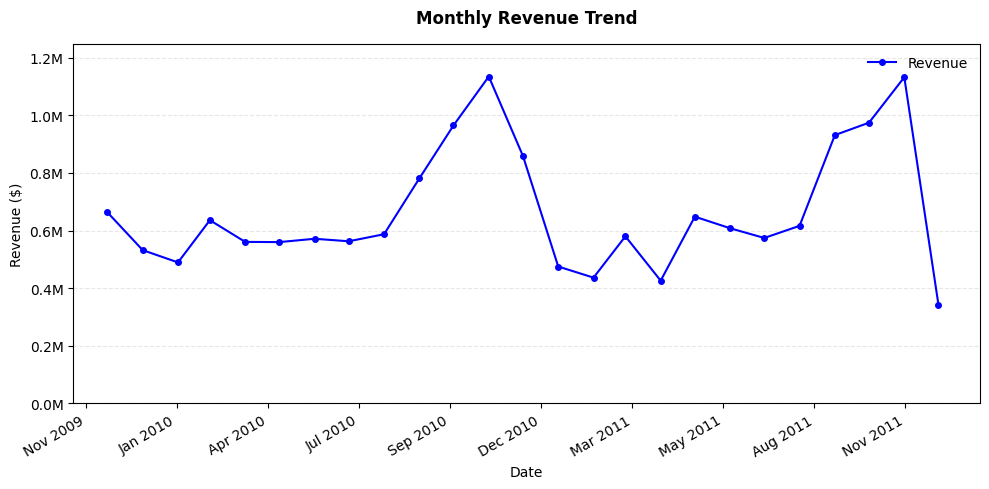

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 5)) # Slightly wider for better date spacing

ax.plot(monthly_revenue['revenue_month'], monthly_revenue['total_revenue'], 
        color='blue', linewidth=1.5, marker='o', markersize=4)

# Using 1 decimal place (e.g., 0.5M) so values don't all round to '1M'
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_ylim(0, monthly_revenue['total_revenue'].max() * 1.1) # Dynamic headroom

# Reducing bins so labels don't overlap
ax.set_xlim(pd.Timestamp('2009-11-01'), None)
ax.xaxis.set_major_locator(MaxNLocator(nbins=10)) # Dropped from 20 to 10 for clarity

# Using month names instead of full YYYY-MM-DD strings
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.set_title('Monthly Revenue Trend', fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Revenue ($)')
ax.legend(['Revenue'], frameon=False, loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.3)
fig.autofmt_xdate() # Rotates dates
fig.tight_layout()
plt.show()

In [9]:
''' import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(monthly_revenue['revenue_month'], monthly_revenue['total_revenue'], color='Blue',
        linewidth=1.2, alpha=1,
        marker='o', markersize=3,markerfacecolor='Blue')
ax.set_xlim(pd.Timestamp('2009-11-01'), None)
ax.set_ylim(0, 1500000)
ax.xaxis.set_major_locator(MaxNLocator(nbins=20, integer=True))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000000:.000f}M'))
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (₹)')
ax.legend(['Revenue'], frameon=False)
fig.tight_layout()
fig.autofmt_xdate()
plt.show() '''

" import matplotlib.pyplot as plt\nfrom matplotlib.ticker import MaxNLocator\nfrom matplotlib.ticker import FuncFormatter\n\nfig, ax = plt.subplots(figsize=(8, 4))\n\nax.plot(monthly_revenue['revenue_month'], monthly_revenue['total_revenue'], color='Blue',\n        linewidth=1.2, alpha=1,\n        marker='o', markersize=3,markerfacecolor='Blue')\nax.set_xlim(pd.Timestamp('2009-11-01'), None)\nax.set_ylim(0, 1500000)\nax.xaxis.set_major_locator(MaxNLocator(nbins=20, integer=True))\nax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000000:.000f}M'))\nax.set_title('Monthly Revenue Trend')\nax.set_xlabel('Date')\nax.set_ylabel('Revenue (₹)')\nax.legend(['Revenue'], frameon=False)\nfig.tight_layout()\nfig.autofmt_xdate()\nplt.show() "

### **5) Chart 2 : Top 10 Customers by Revenue**

In [10]:
customer_metrics

,customer_id,country,total_revenue,total_orders,avg_order_value
0,18102,United Kingdom,598215.22,153,3909.90
1,14646,Netherlands,523342.07,164,3191.11
2,14156,EIRE,296564.69,202,1468.14
3,14911,EIRE,270248.53,510,529.90
4,17450,United Kingdom,233579.39,61,3829.17
...,...,...,...,...,...
5937,16981,United Kingdom,-4620.86,1,-4620.86
5938,15760,Norway,-5795.87,5,-1159.17
5939,15849,United Kingdom,-5876.34,1,-5876.34
5940,12918,United Kingdom,-10953.50,3,-3651.17


In [11]:
df = customer_metrics.sort_values(by='total_revenue',ascending=False).head(10)
df

,customer_id,country,total_revenue,total_orders,avg_order_value
0,18102,United Kingdom,598215.22,153,3909.90
1,14646,Netherlands,523342.07,164,3191.11
2,14156,EIRE,296564.69,202,1468.14
3,14911,EIRE,270248.53,510,529.90
4,17450,United Kingdom,233579.39,61,3829.17
5,13694,United Kingdom,190825.52,164,1163.57
6,17511,United Kingdom,171885.98,85,2022.19
7,12415,Australia,143269.29,33,4341.49
8,16684,United Kingdom,141502.25,65,2176.96
9,15061,United Kingdom,136391.48,138,988.34


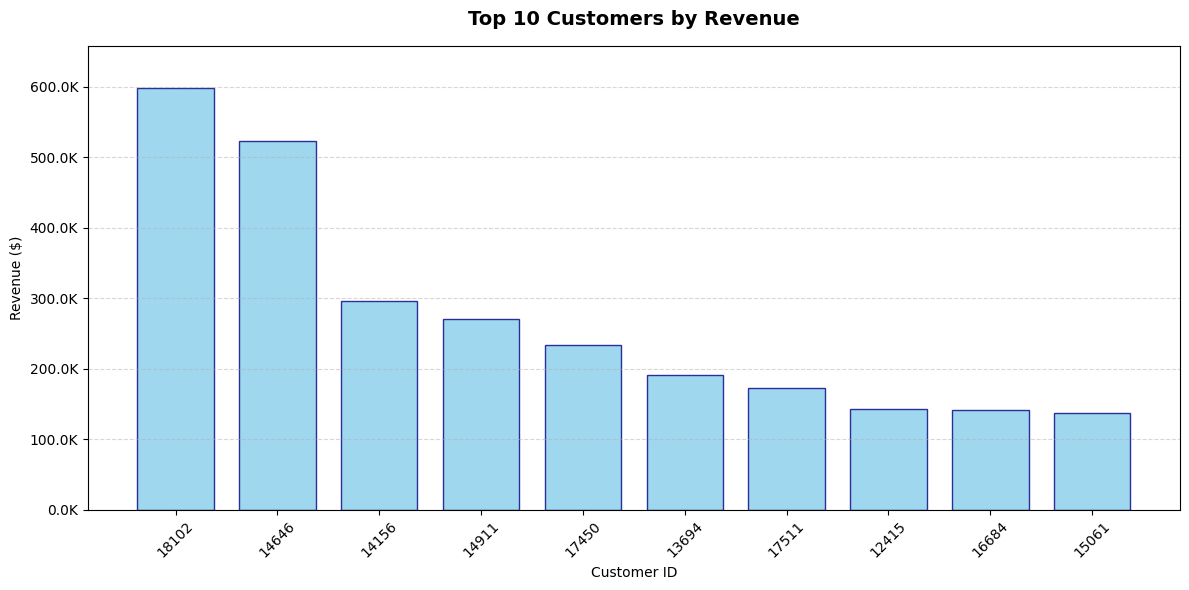

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x=df['customer_id'].astype(str),
    height=df['total_revenue'],
    width=0.75,                      
    color='skyblue',                
    alpha=0.8,                      
    edgecolor='navy',              
    linewidth=1
)

ax.set_ylim(0, df['total_revenue'].max() * 1.1) 

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1000:.1f}K') 
)

ax.tick_params(axis='x', rotation=45)

ax.set_title("Top 10 Customers by Revenue",fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Customer ID")
ax.set_ylabel("Revenue ($)")

ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

### **6) Chart 3 : Top 10 Product by Revenue**

In [13]:
product_metrics

,stock_code,description,total_units_sold,total_revenue
0,22423,REGENCY CAKESTAND 3 TIER,23446,269736.70
1,85123A,CREAM HANGING HEART T-LIGHT HOLDER,90065,242855.86
2,85099B,JUMBO BAG RED RETROSPOT,93766,168440.36
3,84879,ASSORTED COLOUR BIRD ORNAMENT,79434,126354.18
4,POST,POSTAGE,5078,112249.10
...,...,...,...,...
4641,79323B,"Unsaleable, destroyed.",-8,-75.00
4642,20879,TREE OF NOAH FESTIVE SCENTED CANDLE,-34,-161.30
4643,CRUK,CRUK Commission,-16,-7933.43
4644,D,Discount,-2869,-13390.25


In [14]:
df = product_metrics.sort_values(by='total_revenue',ascending=False).head(10)
df

,stock_code,description,total_units_sold,total_revenue
0,22423,REGENCY CAKESTAND 3 TIER,23446,269736.70
1,85123A,CREAM HANGING HEART T-LIGHT HOLDER,90065,242855.86
2,85099B,JUMBO BAG RED RETROSPOT,93766,168440.36
3,84879,ASSORTED COLOUR BIRD ORNAMENT,79434,126354.18
4,POST,POSTAGE,5078,112249.10
5,47566,PARTY BUNTING,23335,102686.23
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,29001,78366.93
7,79321,CHILLI LIGHTS,15591,72229.34
8,22386,JUMBO BAG PINK POLKADOT,37230,67574.16
9,21137,BLACK RECORD COVER FRAME,19606,67127.15


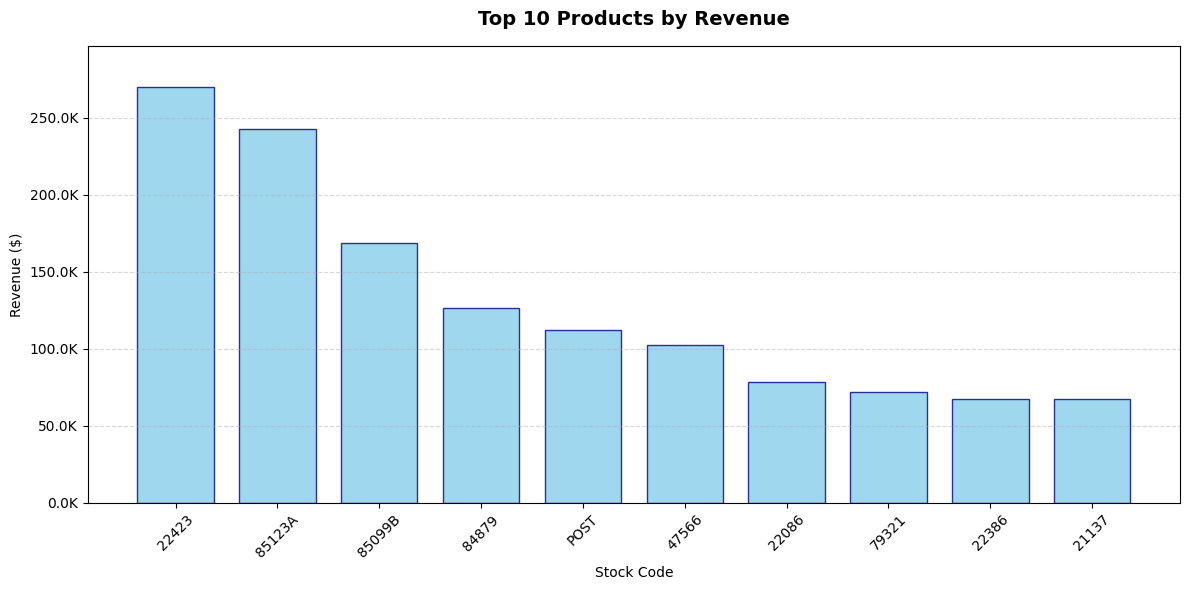

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x=df['stock_code'].astype(str),
    height=df['total_revenue'],
    width=0.75,                      
    color='skyblue',                
    alpha=0.8,                      
    edgecolor='navy',              
    linewidth=1
)

ax.set_ylim(0, df['total_revenue'].max() * 1.1) 

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1000:.1f}K') 
)

ax.tick_params(axis='x', rotation=45)

ax.set_title("Top 10 Products by Revenue",fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Stock Code")
ax.set_ylabel("Revenue ($)")

ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

### **7) Chart 4 : Cohort Retention Heatmap**

In [16]:
retention

,cohort_month,-1,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,20,21,22,23
0,2009-12,1.0,0.375,0.343,0.428,0.392,0.390,0.390,0.358,0.340,...,0.305,0.261,0.302,0.290,0.275,0.262,0.318,0.305,0.409,0.209
1,2010-01,1.0,0.218,0.302,0.305,0.279,0.292,0.266,0.231,0.289,...,0.152,0.218,0.188,0.175,0.185,0.236,0.185,0.223,0.074,NaN
2,2010-02,1.0,0.300,0.226,0.303,0.256,0.209,0.218,0.284,0.275,...,0.204,0.185,0.168,0.146,0.234,0.248,0.171,0.063,NaN,NaN
3,2010-03,1.0,0.218,0.259,0.236,0.229,0.200,0.241,0.298,0.289,...,0.170,0.174,0.158,0.170,0.204,0.213,0.076,NaN,NaN,NaN
4,2010-04,1.0,0.230,0.199,0.162,0.186,0.230,0.271,0.261,0.113,...,0.148,0.141,0.141,0.172,0.210,0.065,NaN,NaN,NaN,NaN
5,2010-05,1.0,0.193,0.177,0.193,0.189,0.260,0.220,0.130,0.067,...,0.130,0.142,0.165,0.157,0.047,NaN,NaN,NaN,NaN,NaN
6,2010-06,1.0,0.216,0.197,0.204,0.230,0.283,0.130,0.093,0.082,...,0.123,0.138,0.204,0.059,NaN,NaN,NaN,NaN,NaN,NaN
7,2010-07,1.0,0.208,0.202,0.284,0.301,0.153,0.115,0.153,0.142,...,0.175,0.246,0.093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2010-08,1.0,0.247,0.316,0.323,0.184,0.133,0.101,0.139,0.146,...,0.203,0.070,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2010-09,1.0,0.302,0.260,0.140,0.091,0.103,0.140,0.099,0.124,...,0.054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
if 'cohort_month' in retention.columns:
    retention = retention.set_index('cohort_month')
elif 'index' in retention.columns: # Sometimes Excel names the date column 'index'
    retention = retention.set_index('index')

# Drop the "Index" Column if it's just numbers
retention = retention.drop(columns=[0], errors='ignore')

# Convert Everything to Numeric
retention = retention.apply(pd.to_numeric, errors='coerce')

# Format Column Headers
retention.columns = [int(float(c)) for c in retention.columns]

# Final Index Formatting
retention.index = pd.to_datetime(retention.index).strftime('%b-%Y')

In [18]:
retention = retention.drop(columns=[-1])

In [19]:
mask = retention.isna()

C:\Users\notya\AppData\Local\Temp\ipykernel_6972\1181892452.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plot_data.index = pd.to_datetime(plot_data.index.astype(str)).strftime('%b-%Y')


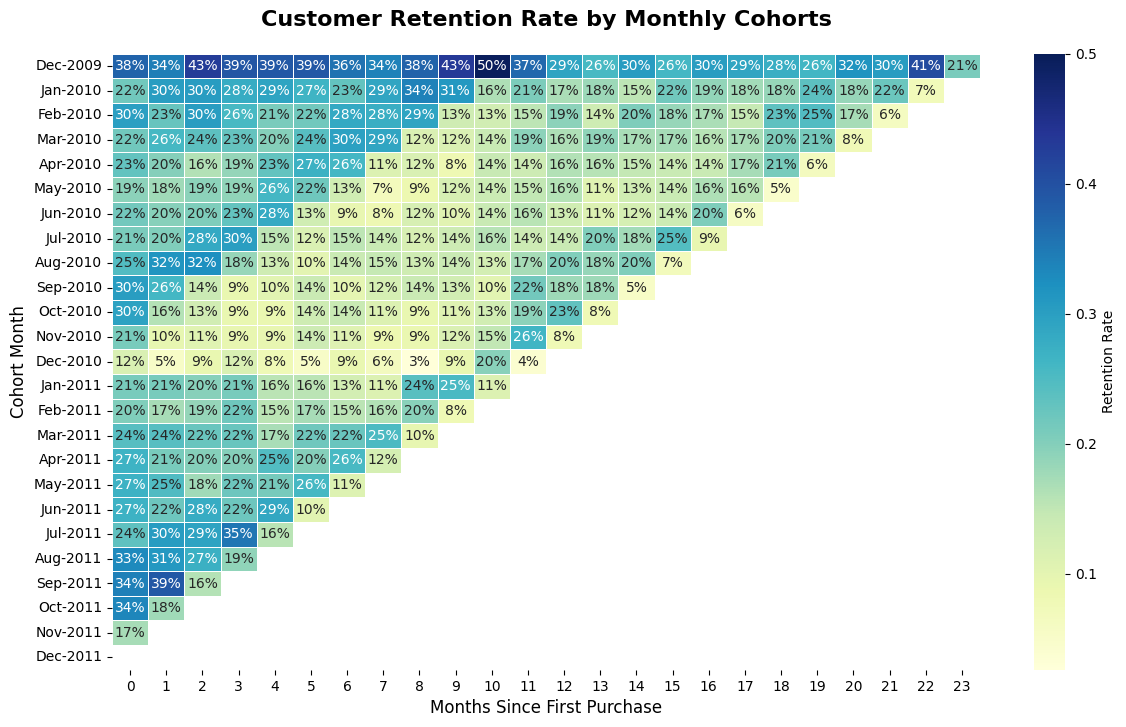

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plot_data = retention.copy()

plot_data.index = pd.to_datetime(plot_data.index.astype(str)).strftime('%b-%Y')

plt.figure(figsize=(14, 8))

sns.heatmap(
    data=plot_data,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    cbar_kws={"label": "Retention Rate"},
    vmax=0.5,
    linewidths=0.5
)

plt.title('Customer Retention Rate by Monthly Cohorts',fontweight='bold',fontsize=16, pad=20)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.show()

### **8) Chart 5 : Actual vs Forecasted Revenue**

In [21]:
forecast

,revenue_month,revenue
0,2009-12,6.632721e+05
1,2010-01,5.319529e+05
2,2010-02,4.893996e+05
3,2010-03,6.359965e+05
4,2010-04,5.606350e+05
5,2010-05,5.599246e+05
6,2010-06,5.714599e+05
7,2010-07,5.627859e+05
8,2010-08,5.872565e+05
9,2010-09,7.810333e+05


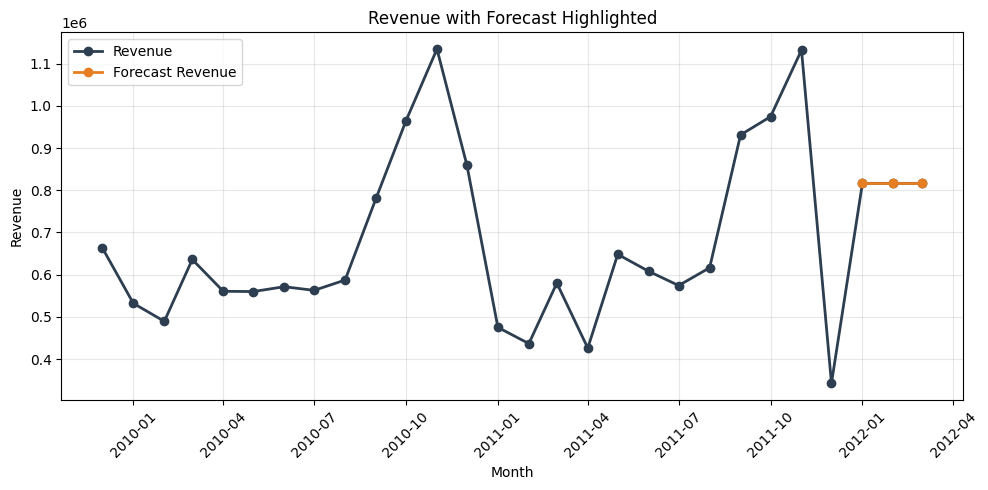

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure revenue_month is datetime
forecast["revenue_month"] = pd.to_datetime(forecast["revenue_month"])

# Split the last 3 points (forecast) automatically
forecast_points = forecast.iloc[-3:]

plt.figure(figsize=(10,5))

# Plot the full continuous line
plt.plot(
    forecast["revenue_month"],
    forecast["revenue"],
    color='#2C3E50',
    marker='o',
    linewidth=2,
    label='Revenue'
)

# Highlight last three forecast points
plt.plot(
    forecast_points["revenue_month"],
    forecast_points["revenue"],
    color='#E67E22',  # different color for forecast
    marker='o',
    linewidth=2,
    label='Forecast Revenue'
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Revenue with Forecast Highlighted")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
